In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_data_dir = os.getcwd()
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_data_dir, '..', '..'))
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
internal_HT_PDC_dir = os.path.abspath(os.path.join(internal_HT_dir, '1_PD_Controllers'))
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_PDC_dir, 'scripts'))
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

In [2]:
internal_CDP_data_dir = os.path.abspath(os.path.join(internal_PDC_data_dir, 'Collected_Data_Python'))
print(internal_CDP_data_dir)

d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\April_25\PD_test_data\Collected_Data_Python


In [5]:
data_list = []
for i in range(len(os.listdir(internal_CDP_data_dir))):
    data_list.append(pd.read_csv(os.path.join(internal_CDP_data_dir, os.listdir(internal_CDP_data_dir)[i])))

In [6]:
data_list[-1].head()

,Ego_Position(m),Ego_Velocity(m/s),Time(s)
0,0.0,0.0,0.000021
1,0.0,0.0,13.368994
2,0.0,0.0,13.480921
3,0.0,0.0,13.593135
4,0.0,0.0,13.704976


In [7]:
def plot(separations, velocities, times = None, Dr = CP.Dr_3, Vp = CP.Vp_3):
    font = 50
    if times is None:
        times = [0.1 * i for i in range(len(separations))]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (60, 25))
    
    plot_separations = [Dr - x for x in separations]
    
    ax1.plot(times, plot_separations, linewidth = 4)
    ax1.plot(times, [CP.Dd + CP.Td * Vp for _ in range(len(plot_separations))], label = f'Desired final seperation', color = 'green', linewidth = 6)
    ax1.grid(True, linewidth = 4)
    ax1.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax1.set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    ax1.set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    ax1.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax1.legend(fontsize = font)
    
    ax2.plot(times, velocities)
    ax2.plot(times, [Vp * 18 / 5 for _ in range(len(velocities))], label = f'Desired final velocity', color = 'green', linewidth = 6)
    ax2.grid(True, linewidth = 4)
    ax2.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax2.set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    ax2.set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    ax2.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax2.legend(fontsize = font)
    
    plt.show()

In [8]:
print(list(data_list[0]['Time(s)']))

[2.24e-05, 0.067260742, 0.178721666, 0.2914083, 0.402698993, 0.514696359, 0.626560688, 0.738471746, 0.850885391, 0.961921215, 1.075186252, 1.185722828, 1.2987113, 1.409574985, 1.522733688, 1.634582996, 1.747259378, 1.858563423, 1.970528125, 2.083126783, 2.19757843, 2.306859016, 2.418449402, 2.531511306, 2.641248941, 2.754634857, 2.865247249, 2.978095531, 3.091266632, 3.201972246, 3.314442157, 3.42637372, 3.539851188, 3.651583194, 3.761880636, 3.874723911, 3.986463308, 4.098699569, 4.211197614, 4.324051857, 4.434118271, 4.546831607, 4.658767938, 4.769382476, 4.882398843, 4.995659828, 5.107562065, 5.218931913, 5.330940246, 5.442513227, 5.555338382, 5.666696548, 5.777373314, 5.89058733, 6.002379894, 6.115008115, 6.226451158, 6.338947534, 6.450533151, 6.562333345, 6.674872398, 6.786356687, 6.898832321, 7.010333538, 7.123364925, 7.238385677, 7.346525907, 7.4585855, 7.570419311, 7.682866573, 7.794013261, 7.907346725, 8.018367052, 8.130692243, 8.242251634, 8.354471206, 8.466471672, 8.57847642

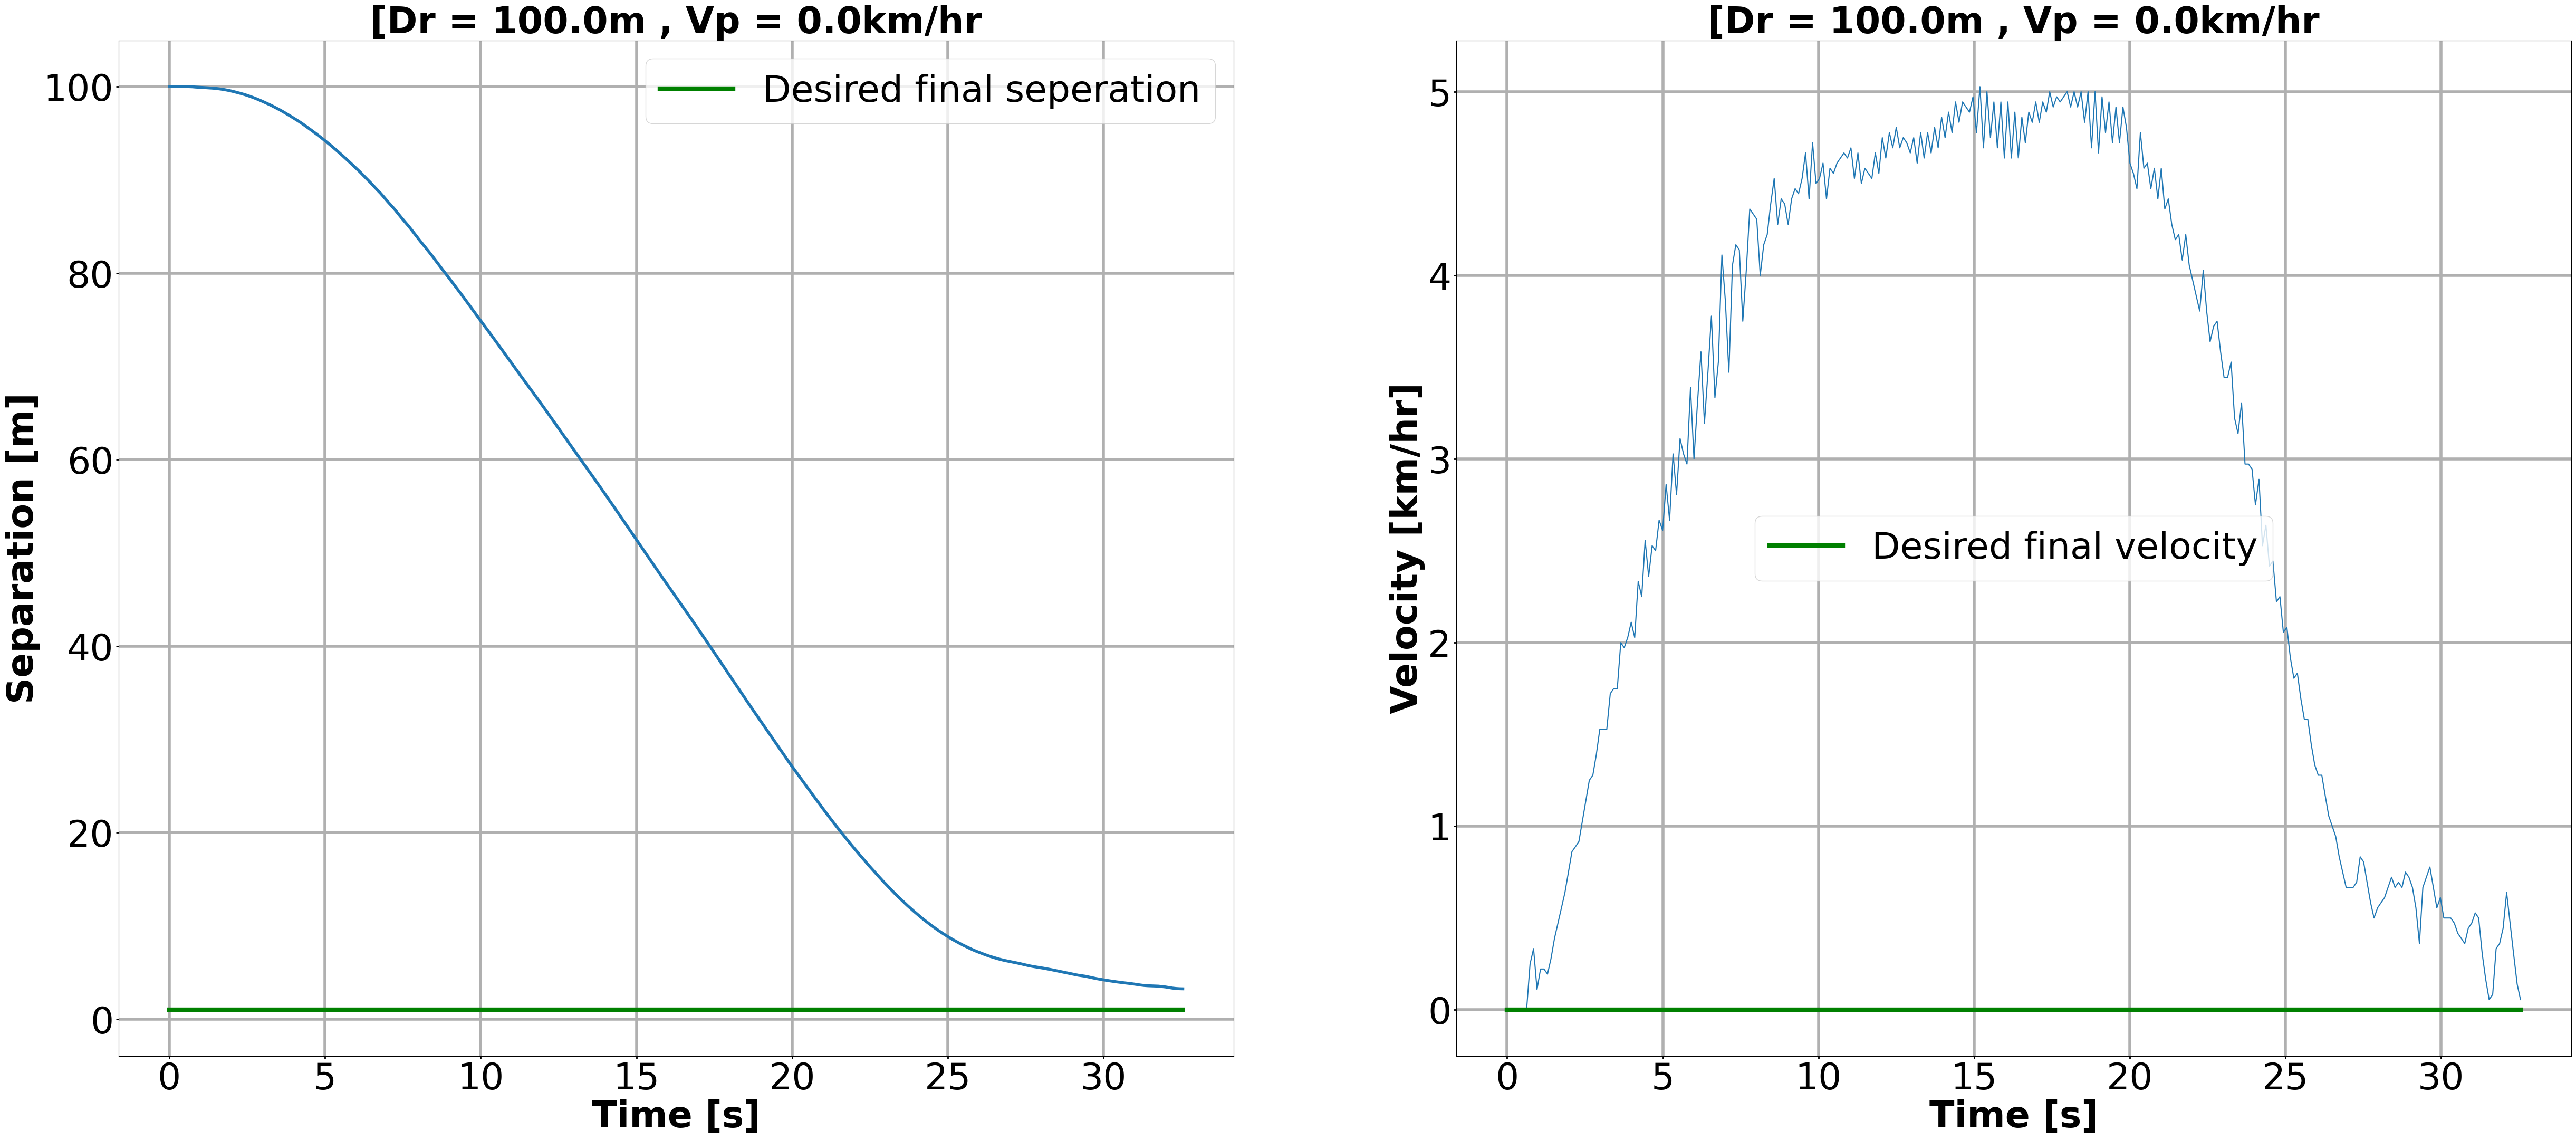

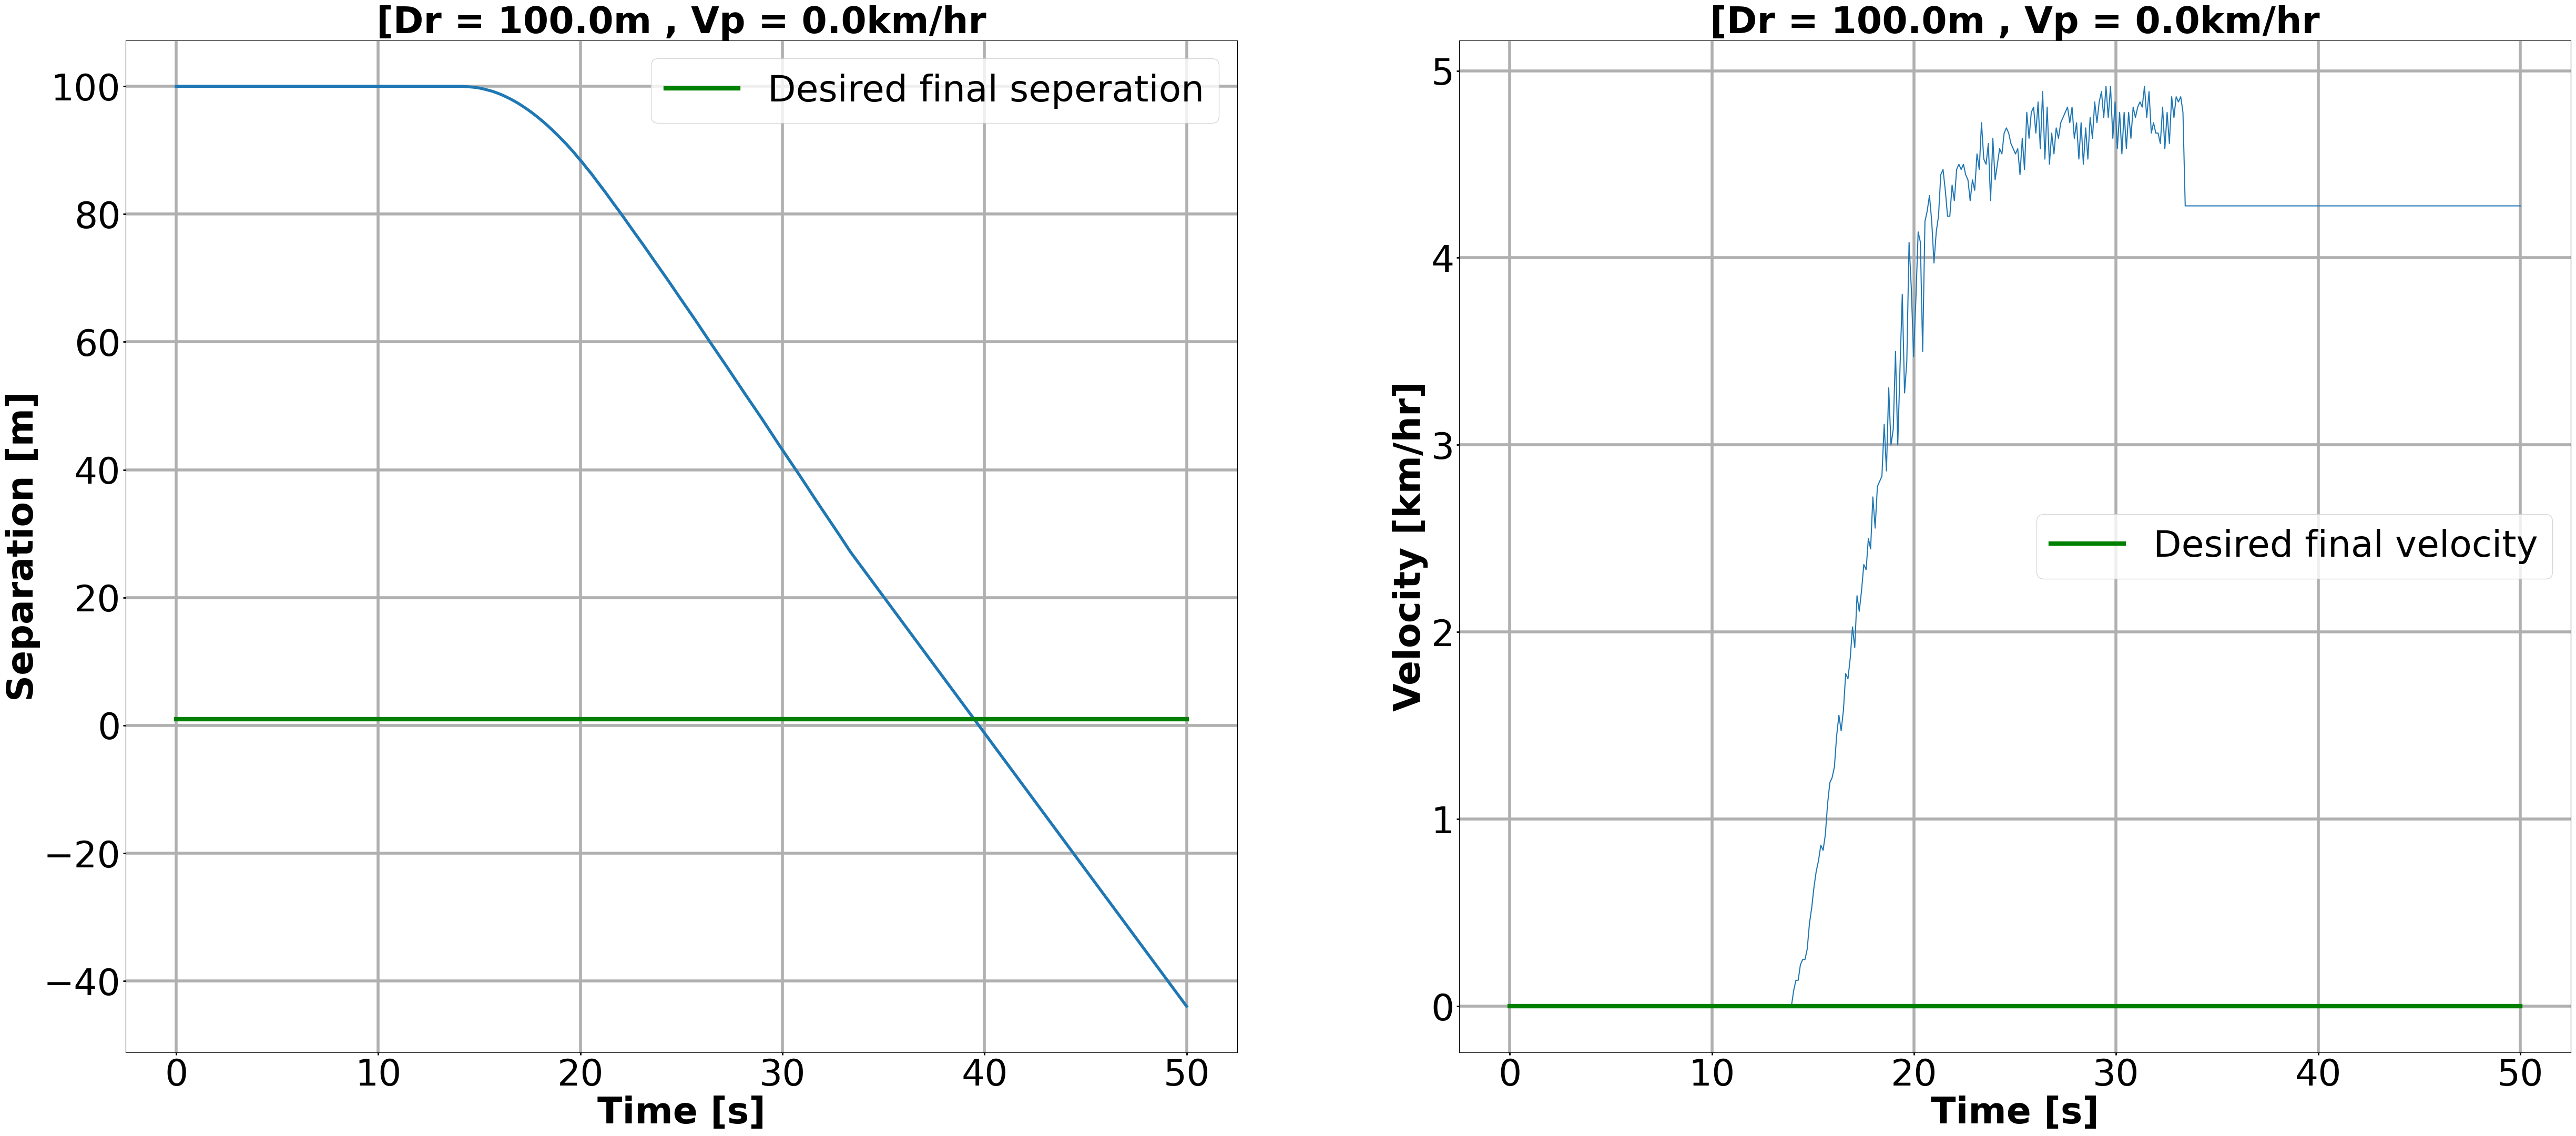

In [9]:
for i in range(len(data_list)):
    plot(list(data_list[i]['Ego_Position(m)']), list(data_list[i]['Ego_Velocity(m/s)']), list(data_list[i]['Time(s)']))

In [ ]:
print(list(data_list[-1]['Ego_Velocity(m/s)']))
print(list(data_list[-1]['Time(s)']))

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.1944444411330753, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 0.7777777645323012, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 1.4166666401757135, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.1388889683617487, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 2.7777777777777777, 3.1111110581292047, 3.1111110581292047, 3.1111110